In [2]:
## S1 - S2: Setup environment  + Load Data
# [1]
import pandas as pd, numpy as np
import xgboost as xgb
import shap
import pandas as pd
print("Environment OK")

# [2]
df = pd.read_csv('../data/paysim.csv')
print(f"Shape: {df.shape}")

# [3]
df.info()
# Output: tên 11 cột, dtype từng cột, và bộ nhớ dùng. 
# Kết quả là bằng chứng cụ thể cho phần "Data Understanding"

# [4]
# Dữ liệu thật hình dung rõ hơn con số trong từng cột trông như thế nào
df.head(10)

# [5]
# Kiểm tra giá trị null
df.isnull().sum()

# [6]
# Kiểm tra duplicate
df.duplicated().sum()

# [7]
# Thống kê mô tả cơ bản
df.describe()

# [8]
# Kiểm tra giá trị duy nhất của các cột phân loại
df['type'].value_counts()
df['isFraud'].value_counts()
df['isFlaggedFraud'].value_counts()

# [9]
# Verify ý nghĩa step
#Kỳ vọng: min = 1, max = 743 hoặc 744 → xác nhận đúng "1 step = 1 giờ, tổng ~30 ngày" (744 giờ = 31 ngày).
df['step'].min(), df['step'].max()

# Verify fraud chỉ xảy ra ở TRANSFER và CASH_OUT
# Đây là câu lệnh quan trọng nhất ngày 2 — nó tự tay kiểm chứng insight mà bạn đã ghi trong memory ("fraud chỉ xảy ra ở TRANSFER và CASH_OUT"). Nếu kết quả đúng như vậy (chỉ ra 2 loại này, không có PAYMENT/CASH_IN/DEBIT), bạn có bằng chứng chắc chắn để viết vào cả Data Understanding lẫn Discussion/Limitations sau này.
df[df['isFraud'] == 1]['type'].value_counts()

# Verify công thức số dư có khớp logic không
# Kiểm tra vài dòng xem oldbalanceOrg - amount có gần bằng newbalanceOrig không
# Giúp bạn hiểu tại sao paper (và bạn ở tuần 1 ngày 4) cần tạo errorBalanceOrig — vì thực tế nhiều dòng số dư không khớp hoàn toàn với phép trừ đơn giản (có sai lệch), và bản thân độ lệch đó lại là tín hiệu hữu ích để phát hiện gian lận.
df[['oldbalanceOrg', 'amount', 'newbalanceOrig']].head(10)

# Thử vài giao dịch fraud thật để có cảm giác trực quan
# Đọc bằng mắt vài dòng — bạn sẽ thấy rõ pattern "rút cạn tài khoản" (newbalanceOrig gần như luôn = 0 sau giao dịch) mà không cần chờ đến bước EDA vẽ biểu đồ mới thấy.
df[df['isFraud'] == 1].head(10)

Environment OK
Shape: (6362620, 11)
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.00,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.0,0.00,1,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.00,1,0
681,1,CASH_OUT,20128.00,C1118430673,20128.00,0.0,C339924917,6268.0,12145.85,1,0
724,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.0,9291619.62,1,0
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.00,1,0
970,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.0,2444985.19,1,0
1115,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.00,1,0


isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


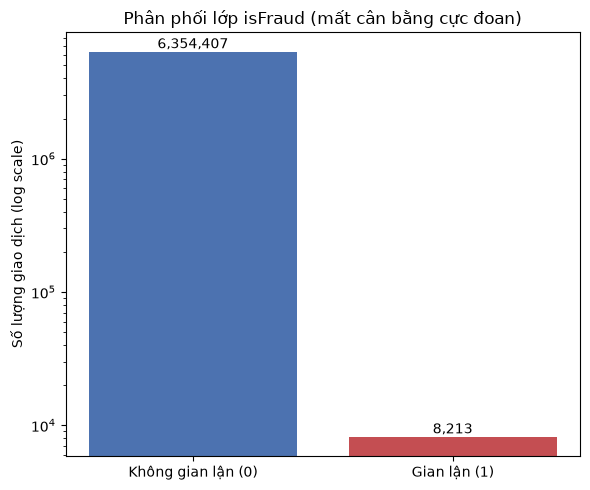

          Không gian lận  Gian lận
type                              
CASH_IN          1399284         0
CASH_OUT         2233384      4116
DEBIT              41432         0
PAYMENT          2151495         0
TRANSFER          528812      4097
type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


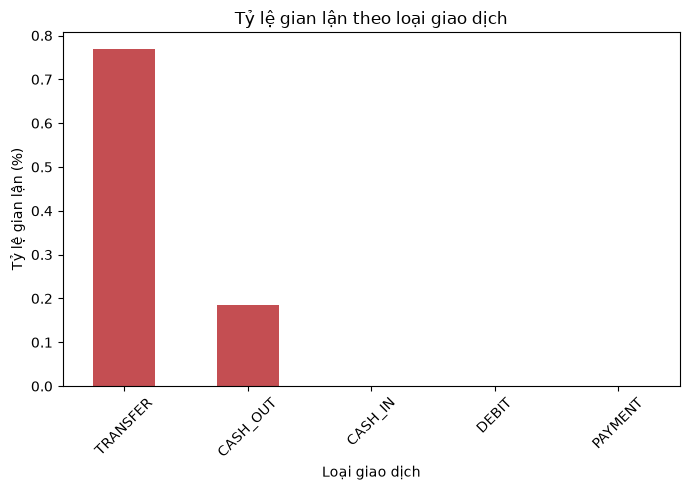

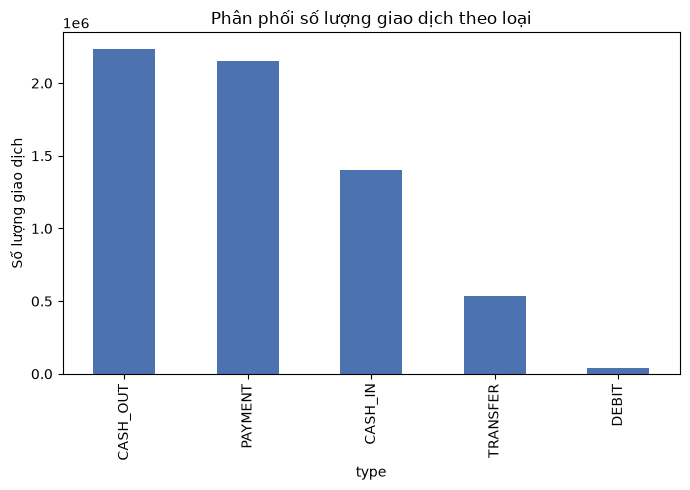

In [ ]:
## S3: EDA - Class imbalance + Transaction type

# [10] : Phân tích class imbalance
# 10.1: Tính tỷ lệ chính xác
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print(fraud_counts)
print(fraud_pct)

# 10.2: Vẽ biểu đồ ( bar chart, log scale )
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#4C72B0', '#C44E52']
bars = ax.bar(['Không gian lận (0)', 'Gian lận (1)'], fraud_counts.values, color=colors)
ax.set_yscale('log')
ax.set_ylabel('Số lượng giao dịch (log scale)')
ax.set_title('Phân phối lớp isFraud (mất cân bằng cực đoan)')

# Thêm số liệu thật lên đầu mỗi cột cho dễ đọc
for bar, count in zip(bars, fraud_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{count:,}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/class_imbalance.png', dpi=150)
plt.show()

# [11]: Phân tích theo transaction type
# 11.1: Crosstab tổng quát
ct = pd.crosstab(df['type'], df['isFraud'])
ct.columns = ['Không gian lận', 'Gian lận']
print(ct)

# 11.2: Tính tỷ lệ fraud theo từng type
fraud_rate_by_type = df.groupby('type')['isFraud'].mean() * 100
print(fraud_rate_by_type.sort_values(ascending=False))

# 11.3: Vẽ biểu đồ tỷ lệ fraud theo type
fig, ax = plt.subplots(figsize=(7, 5))
fraud_rate_by_type.sort_values(ascending=False).plot(kind='bar', ax=ax, color='#C44E52')
ax.set_ylabel('Tỷ lệ gian lận (%)')
ax.set_xlabel('Loại giao dịch')
ax.set_title('Tỷ lệ gian lận theo loại giao dịch')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/fraud_rate_by_type.png', dpi=150)
plt.show()

# 11.4: Biểu đồ phân phối tổng thể transaction type
fig, ax = plt.subplots(figsize=(7, 5))
df['type'].value_counts().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_ylabel('Số lượng giao dịch')
ax.set_title('Phân phối số lượng giao dịch theo loại')
plt.tight_layout()
plt.savefig('../reports/figures/transaction_type_distribution.png', dpi=150)
plt.show()


# [12]: Phân phối amount - fraud & non-fraud
# 12.1: Thống kê mô tả so sánh
print(df[df['isFraud']==0]['amount'].describe())
print(df[df['isFraud']==1]['amount'].describe())

# 12.2: Vẽ boxplot ( log scale )
fig, ax = plt.subplots(figsize=(7, 5))
# Lọc chỉ TRANSFER và CASH_OUT vì đây là nơi fraud thực sự xảy ra
subset = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
sns.boxplot(data=subset, x='isFraud', y='amount', ax=ax)
ax.set_yscale('log')
ax.set_xticklabels(['Không gian lận', 'Gian lận'])
ax.set_ylabel('Số tiền giao dịch (log scale)')
ax.set_title('Phân phối số tiền giao dịch theo trạng thái gian lận\n(chỉ TRANSFER & CASH_OUT)')

plt.tight_layout()
plt.savefig('../reports/figures/amount_distribution_fraud.png', dpi=150)
plt.show()